In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
import glob
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [3]:
NON_REASONING_MODELS = ['gpt-4o', 'claude-haiku-4-5', 'qwen-coder', 'llama-4', 'gpt-oss-120b']
REASONING_MODELS = ['gpt-5.2', 'deepseek-v3.1', 'qwen3-235b-thinking', 'qwen3-next-thinking']
ALL_MODELS = NON_REASONING_MODELS + REASONING_MODELS

# Nice display names & colors
MODEL_DISPLAY = {
    'gpt-4o': 'GPT-4o',
    'claude-haiku-4-5': 'Claude-Haiku-4.5',
    'qwen-coder': 'Qwen3-Coder-480B',
    'llama-4': 'Llama-4-Maverick',
    'gpt-5.2': 'GPT-5.2 ★',
    'deepseek-v3.1': 'DeepSeek-V3.1 ★',
    'qwen3-235b-thinking': 'Qwen3-235B-Think ★',
    'qwen3-next-thinking': 'Qwen3-Next-Think ★',
    'gpt-oss-120b': 'GPT-OSS-120B',
}

# MODEL_COLORS = {
#     'gpt-4o': '#1f77b4',
#     'qwen-coder': '#ff7f0e',
#     'llama-4': '#2ca02c',
#     'gpt-5.2': '#d62728',
#     'deepseek-v3.1': '#9467bd',
#     'qwen3-235b-thinking': '#8c564b',
#     'qwen3-next-thinking': '#e377c2',
# }

print(f"Non-reasoning models: {NON_REASONING_MODELS}")
print(f"Reasoning models:     {REASONING_MODELS}")

Non-reasoning models: ['gpt-4o', 'claude-haiku-4-5', 'qwen-coder', 'llama-4', 'gpt-oss-120b']
Reasoning models:     ['gpt-5.2', 'deepseek-v3.1', 'qwen3-235b-thinking', 'qwen3-next-thinking']


In [4]:
df_all = pd.read_csv('/data/jane/convert/math_gender/conversion_test/temp.csv', sep='\t')
df_all.head()

/tmp/ipykernel_1291258/629096885.py:1: DtypeWarning: Columns (1,3,4,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all = pd.read_csv('/data/jane/convert/math_gender/conversion_test/temp.csv', sep='\t')


,domain,distractor,prompt,number,answer,difficulty,raw_response,model_answer,loss,reasoning_tokens,call_seconds,model,condition,frequency,frequency_level,is_reasoning,display_name,is_correct,num_decimals,num_input_decimals
0,bits_bytes,NaN,Convert 1 bit to byte.\n\nConversion guide:\nC...,1,0.125,Easy,<answer>0.125</answer>,0.125,0.0,0.0,0.952075,claude-haiku-4-5,in_domain_with_guide,858798582.0,very_common,False,Claude-Haiku-4.5,True,3,0
1,bits_bytes,NaN,Convert 2 bits to bytes.\n\nConversion guide:\...,2,0.25,Easy,<answer>0.25</answer>,0.25,0.0,0.0,0.784189,claude-haiku-4-5,in_domain_with_guide,789731532.0,very_common,False,Claude-Haiku-4.5,True,2,0
2,bits_bytes,NaN,Convert 3 bits to bytes.\n\nConversion guide:\...,3,0.375,Easy,<answer>0.375</answer>,0.375,0.0,0.0,1.045382,claude-haiku-4-5,in_domain_with_guide,423151867.0,very_common,False,Claude-Haiku-4.5,True,3,0
3,bits_bytes,NaN,Convert 4 bits to bytes.\n\nConversion guide:\...,4,0.5,Easy,<answer>0.5</answer>,0.5,0.0,0.0,0.797973,claude-haiku-4-5,in_domain_with_guide,298385028.0,very_common,False,Claude-Haiku-4.5,True,1,0
4,bits_bytes,NaN,Convert 5 bits to bytes.\n\nConversion guide:\...,5,0.625,Easy,<answer>0.625</answer>,0.625,0.0,0.0,1.272115,claude-haiku-4-5,in_domain_with_guide,246823466.0,very_common,False,Claude-Haiku-4.5,True,3,0


In [5]:
df_all.dtypes

domain                 object
distractor             object
prompt                 object
number                 object
answer                 object
difficulty             object
raw_response           object
model_answer           object
loss                  float64
reasoning_tokens      float64
call_seconds          float64
model                  object
condition              object
frequency             float64
frequency_level        object
is_reasoning             bool
display_name           object
is_correct               bool
num_decimals            int64
num_input_decimals      int64
dtype: object

In [6]:
# investigate long raw responses

df_all['raw_response_length'] = df_all['raw_response'].astype(str).str.len()


In [7]:
pd.set_option('display.max_colwidth', None)

In [8]:
df_all[(df_all['raw_response_length'] > 30) & (df_all['model'] == 'gpt-4o')]

,domain,distractor,prompt,number,answer,difficulty,raw_response,model_answer,loss,reasoning_tokens,...,model,condition,frequency,frequency_level,is_reasoning,display_name,is_correct,num_decimals,num_input_decimals,raw_response_length
262678,currency,NaN,Convert 28 EUR to JPY.\n\nConversion guide:\nExchange rates (relative to USD):\n GBP: 0.73\n CHF: 0.78\n EUR: 0.85\n USD: 1.0\n CAD: 1.37\n AUD: 1.44\n CNH: 6.94\n SLL: 24.48\n JPY: 155.5\n GNF: 8751.0\n UZS: 12250.0\n IDR: 16766.0\n LAK: 21495.0\n VND: 26019.92\n LBP: 85550.0\n IRR: 1189712.0\n\nProvide only the numerical value.,28.0,5122.352941,Easy,"To convert 28 EUR to JPY, we first convert EUR to USD, then USD to JPY.\n\n1. Convert EUR to USD:\n 28 EUR * (1 USD / 0.85 EUR) = 32.9412 USD\n\n2. Convert USD to JPY:\n 32.9412 USD * 155.5 JPY/USD = 5121.1016 JPY\n\n<answer>5121.1016</answer>",5121.1016,0.000000,0.0,...,gpt-4o,in_domain_with_guide,25865267.0,very_common,False,GPT-4o,True,4,0,239
262688,currency,NaN,Convert 55 EUR to JPY.\n\nConversion guide:\nExchange rates (relative to USD):\n GBP: 0.73\n CHF: 0.78\n EUR: 0.85\n USD: 1.0\n CAD: 1.37\n AUD: 1.44\n CNH: 6.94\n SLL: 24.48\n JPY: 155.5\n GNF: 8751.0\n UZS: 12250.0\n IDR: 16766.0\n LAK: 21495.0\n VND: 26019.92\n LBP: 85550.0\n IRR: 1189712.0\n\nProvide only the numerical value.,55.0,10061.764706,Easy,"To convert 55 EUR to JPY, we first convert EUR to USD, then USD to JPY.\n\n1. Convert EUR to USD:\n 55 EUR * (1 USD / 0.85 EUR) = 64.7059 USD\n\n2. Convert USD to JPY:\n 64.7059 USD * 155.5 JPY/USD = 10064.4195 JPY\n\n<answer>10064.4195</answer>",10064.4195,0.000000,0.0,...,gpt-4o,in_domain_with_guide,10725928.0,very_common,False,GPT-4o,True,4,0,241
262694,currency,NaN,Convert 75 EUR to JPY.\n\nConversion guide:\nExchange rates (relative to USD):\n GBP: 0.73\n CHF: 0.78\n EUR: 0.85\n USD: 1.0\n CAD: 1.37\n AUD: 1.44\n CNH: 6.94\n SLL: 24.48\n JPY: 155.5\n GNF: 8751.0\n UZS: 12250.0\n IDR: 16766.0\n LAK: 21495.0\n VND: 26019.92\n LBP: 85550.0\n IRR: 1189712.0\n\nProvide only the numerical value.,75.0,13720.588235,Easy,"To convert 75 EUR to JPY, we first convert EUR to USD, then USD to JPY.\n\n1. Convert EUR to USD:\n 75 EUR * (1 USD / 0.85 EUR) = 88.2353 USD\n\n2. Convert USD to JPY:\n 88.2353 USD * 155.5 JPY/USD = 13715.2942 JPY\n\n<answer>13715.2942</answer>",13715.2942,0.000000,0.0,...,gpt-4o,in_domain_with_guide,10590900.0,very_common,False,GPT-4o,True,4,0,241
262700,currency,NaN,Convert 99 EUR to JPY.\n\nConversion guide:\nExchange rates (relative to USD):\n GBP: 0.73\n CHF: 0.78\n EUR: 0.85\n USD: 1.0\n CAD: 1.37\n AUD: 1.44\n CNH: 6.94\n SLL: 24.48\n JPY: 155.5\n GNF: 8751.0\n UZS: 12250.0\n IDR: 16766.0\n LAK: 21495.0\n VND: 26019.92\n LBP: 85550.0\n IRR: 1189712.0\n\nProvide only the numerical value.,99.0,18111.176471,Easy,"To convert 99 EUR to JPY, we first convert EUR to USD, then USD to JPY.\n\n1. Convert EUR to USD:\n 99 EUR * (1 USD / 0.85 EUR) = 116.4706 USD\n\n2. Convert USD to JPY:\n 116.4706 USD * 155.5 JPY/USD = 18110.1183 JPY\n\n<answer>18110.1183</answer>",18110.1183,0.000000,0.0,...,gpt-4o,in_domain_with_guide,7752192.0,common,False,GPT-4o,True,4,0,243
262709,currency,NaN,Convert 175 EUR to JPY.\n\nConversion guide:\nExchange rates (relative to USD):\n GBP: 0.73\n CHF: 0.78\n EUR: 0.85\n USD: 1.0\n CAD: 1.37\n AUD: 1.44\n CNH: 6.94\n SLL: 24.48\n JPY: 155.5\n GNF: 8751.0\n UZS: 12250.0\n IDR: 16766.0\n LAK: 21495.0\n VND: 26019.92\n LBP: 85550.0\n IRR: 1189712.0\n\nProvide only the numerical value.,175.0,32014.705882,Easy,"To convert 175 EUR to JPY, we first convert EUR to USD, then USD to JPY.\n\n1. Convert EUR to USD:\n 175 EUR * (1 USD / 0.85 EUR) = 205.8824 USD\n\n2. Convert USD to JPY:\n 205.8824 USD * 155.5 JPY/USD = 32000.0 JPY\n\n<answer>32000.0</answer>",32000.0,0.000000,0.0,...,gpt-4o,in_domain_with_guide,2086492.0,common,False,GPT-4o,True,0,0,239
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2007190,volume,bubble gum,Convert 9.8066 teaspoons of b

In [9]:
df_all['is_correct'] = df_all['loss'] == 0.0

In [10]:
df_all.isna().sum()

domain                       0
distractor              693216
prompt                       0
number                       0
answer                       0
difficulty                   0
raw_response             28012
model_answer             43724
loss                     43724
reasoning_tokens       1378220
call_seconds           1036664
model                        0
condition                    0
frequency                    0
frequency_level              0
is_reasoning                 0
display_name                 0
is_correct                   0
num_decimals                 0
num_input_decimals           0
raw_response_length          0
dtype: int64

In [11]:
len(df_all[df_all['model'] == 'gpt-4o'])

489102

In [12]:
26203/489102

0.05357369219508405

In [13]:
df_stats = pd.read_csv('/data/jane/convert/math_gender/conversion_test/stats.csv', sep='\t')

In [ ]:
df_all[(df_all['condition'] == 'in_domain_with_guide') & (df_all['is_correct'] == False) & (df_all['raw_response_length'] > 30)]

In [15]:
no_guide = df_all[df_all['condition'] == 'in_domain_no_guide']
no_guide = no_guide[~no_guide['model'].isin(['claude-haiku-4-5', 'gpt-oss-120b'])]

n_models = no_guide['model'].nunique()
prompts_in_all = no_guide.groupby('prompt')['model'].nunique()
shared_prompts = prompts_in_all[prompts_in_all == n_models].index
no_guide = no_guide[no_guide['prompt'].isin(shared_prompts)]

print(f"Models: {n_models}, shared prompts: {len(shared_prompts):,}, rows: {len(no_guide):,}")
no_guide.groupby("model").count()

Models: 6, shared prompts: 202,535, rows: 1,215,306


,domain,distractor,prompt,number,answer,difficulty,raw_response,model_answer,loss,reasoning_tokens,call_seconds,condition,frequency,frequency_level,is_reasoning,display_name,is_correct,num_decimals,num_input_decimals,raw_response_length
model,,,,,,,,,,,,,,,,,,,,
deepseek-v3.1,202551,180000,202551,202551,202551,202551,202551,202136,202136,202534,202534,202551,202551,202551,202551,202551,202551,202551,202551,202551
gpt-4o,202551,180000,202551,202551,202551,202551,202551,202546,202546,12400,12400,202551,202551,202551,202551,202551,202551,202551,202551,202551
gpt-5.2,202551,180000,202551,202551,202551,202551,202551,202286,202286,12400,12400,202551,202551,202551,202551,202551,202551,202551,202551,202551
llama-4,202551,180000,202551,202551,202551,202551,202551,202528,202528,102982,102982,202551,202551,202551,202551,202551,202551,202551,202551,202551
qwen-coder,202551,180000,202551,202551,202551,202551,202551,202541,202541,101711,101711,202551,202551,202551,202551,202551,202551,202551,202551,202551
qwen3-235b-thinking,202551,180000,202551,202551,202551,202551,202551,201335,201335,10647,176602,202551,202551,202551,202551,202551,202551,202551,202551,202551


In [16]:
df_all = df_all.dropna(subset=['frequency'])
df_all['frequency'] = df_all['frequency'].clip(lower=1)
df_all['frequency_level'] = pd.qcut(
    np.log10(df_all['frequency']),
    q=4,
    labels=['rare', 'uncommon', 'common', 'very_common'],
)

print(df_all['frequency_level'].value_counts())
print(f"\nLog10 quantile boundaries:")
log_q = np.log10(df_all['frequency']).quantile([0, 0.25, 0.5, 0.75, 1.0])
print(pd.DataFrame({'log10_freq': log_q, 'freq': 10**log_q}).round(1))

frequency_level
rare           745356
very_common    734886
common         731502
uncommon       731472
Name: count, dtype: int64

Log10 quantile boundaries:
      log10_freq         freq
0.00         0.0          1.0
0.25         2.0         99.0
0.50         4.6      36334.0
0.75         6.9    7902842.0
1.00         8.9  858798582.0


In [17]:
df_all.columns

Index(['domain', 'distractor', 'prompt', 'number', 'answer', 'difficulty',
       'raw_response', 'model_answer', 'loss', 'reasoning_tokens',
       'call_seconds', 'model', 'condition', 'frequency', 'frequency_level',
       'is_reasoning', 'display_name', 'is_correct', 'num_decimals',
       'num_input_decimals', 'raw_response_length'],
      dtype='object')

In [18]:
df_stats.columns

Index(['model', 'condition', 'domain', 'accuracy', 'n', 'accuracy_%',
       'domain_difficulty'],
      dtype='object')

In [41]:
# (won't be needed later) drop qwen3-next
df_all = df_all[df_all['model'] != 'qwen3-next-thinking']

In [42]:
df_all['model'].unique()

array(['claude-haiku-4-5', 'deepseek-v3.1', 'gpt-4o', 'gpt-5.2',
       'gpt-oss-120b', 'llama-4', 'qwen-coder', 'qwen3-235b-thinking'],
      dtype=object)

In [38]:
df_stats = df_stats[df_stats['model'] != 'qwen3-next-thinking']

## visualizations!

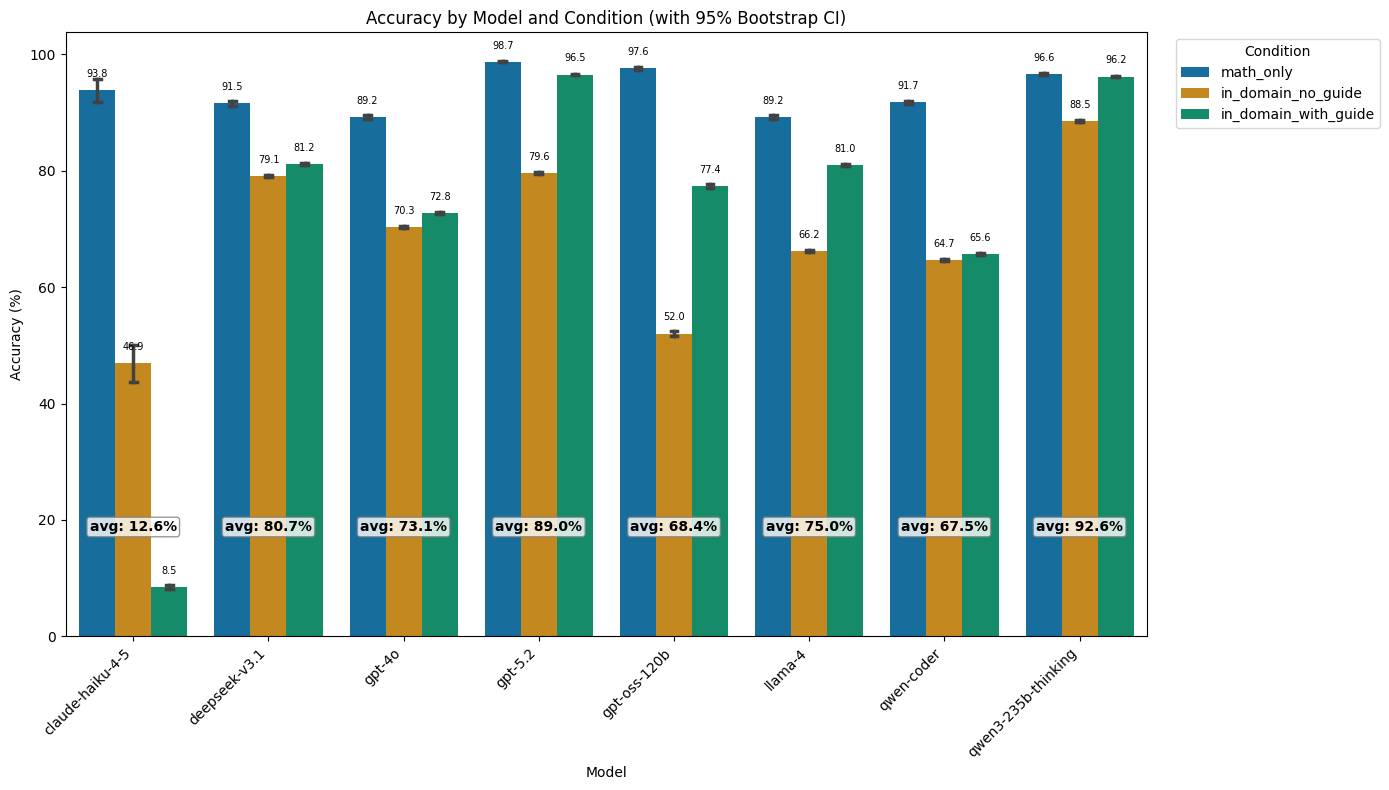

In [43]:
# bar graph - compare math vs natural langauge vs guide

# bar plot of accuracy by model & condition — models on x-axis, condition as hue
# multiply is_correct by 100 so y-axis is in percent
df_all['is_correct_pct'] = df_all['is_correct'].astype(float) * 100

plt.figure(figsize=(14, 8))
ax = sns.barplot(
    data=df_all, x='model', y='is_correct_pct', hue='condition',
    hue_order=['math_only', 'in_domain_no_guide', 'in_domain_with_guide'],
    errorbar=('ci', 95), n_boot=10000, seed=42,
    palette='colorblind',
    errwidth=2.5, capsize=0.15,   # thicker whiskers, wider caps
)

plt.title('Accuracy by Model and Condition (with 95% Bootstrap CI)')
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
plt.legend(title='Condition', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')

# add accuracy labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', fontsize=7, padding=8)

# add average accuracy label for each model (across conditions)
model_avg = df_all.groupby('model')['is_correct_pct'].mean()
for i, tick in enumerate(ax.get_xticklabels()):
    label = tick.get_text()
    if label in model_avg.index:
        avg = model_avg[label]
        ax.text(i, 20, f'avg: {avg:.1f}%', ha='center', va='top',
                fontsize=10, fontweight='bold', color='black',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='gray', alpha=0.8))

plt.tight_layout()
plt.show()

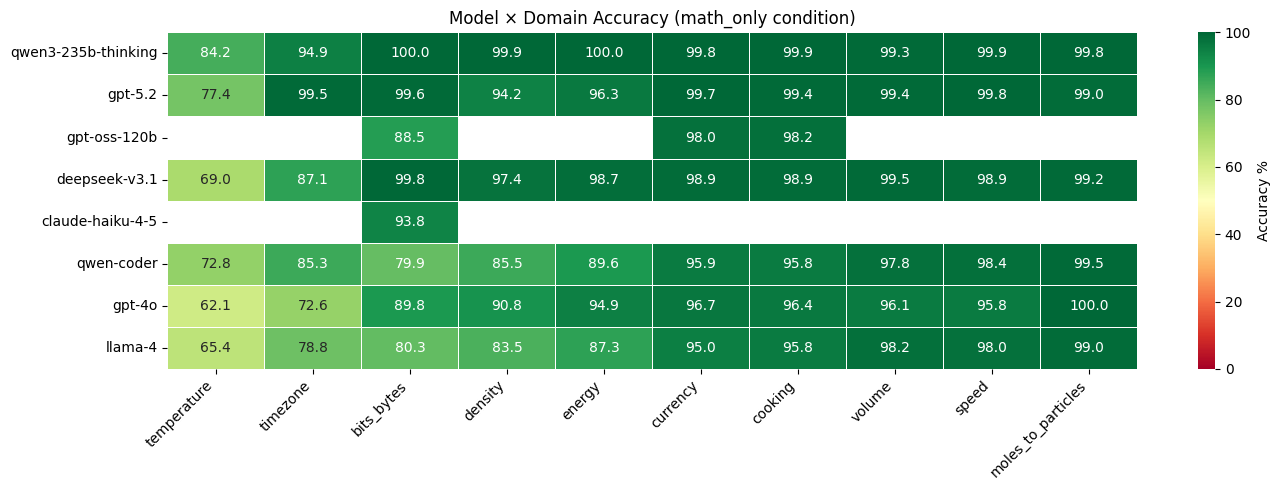

In [32]:
# heatmaps

# make a math only heatmap of accuracy by model, condition
heatmap_data = (
    df_stats[df_stats['condition'] == 'math_only']
    .pivot(index='model', columns='domain', values='accuracy_%')
)
# sort rows (models) and columns (domains) by average accuracy descending
heatmap_data = heatmap_data.loc[heatmap_data.mean(axis=1).sort_values(ascending=False).index,
                                heatmap_data.mean(axis=0).sort_values(ascending=True).index]

plt.figure(figsize=(14, 5))
sns.heatmap(
    heatmap_data,
    annot=True, fmt='.1f',       # show numbers in cells
    cmap='RdYlGn',      
    vmin=0, vmax=100,
    linewidths=0.5,
    cbar_kws={'label': 'Accuracy %'},
)
plt.title('Model × Domain Accuracy (math_only condition)')
plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

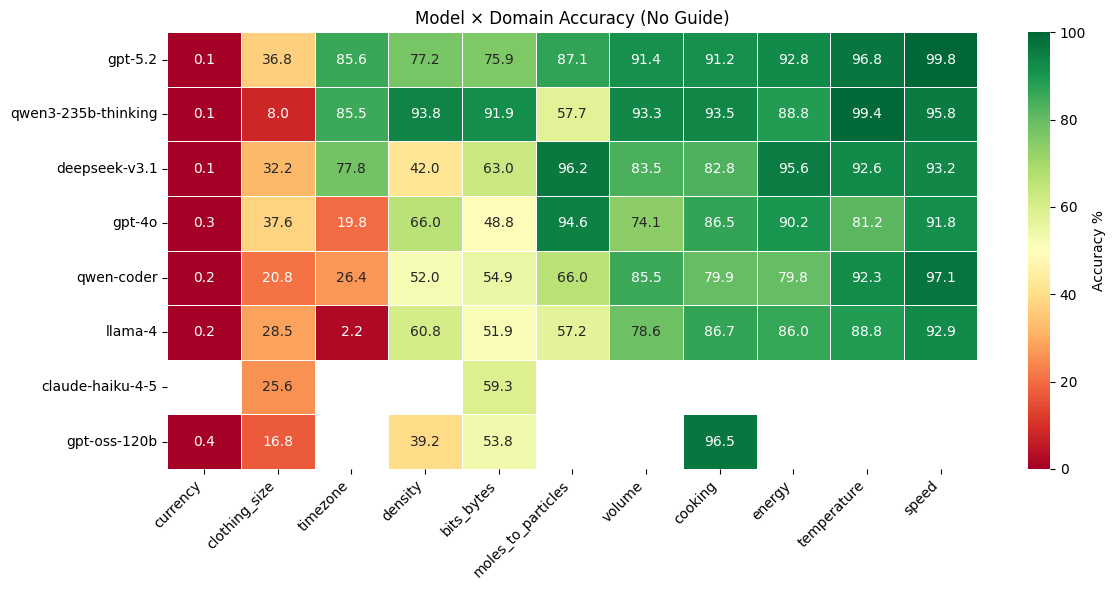

In [33]:
# make a no guide heatmap of accuracy by model, condition
heatmap_data_no_guide = (
    df_stats[df_stats['condition'] == 'in_domain_no_guide']
    .pivot(index='model', columns='domain', values='accuracy_%')
)
# sort rows (models) and columns (domains) by average accuracy descending
heatmap_data_no_guide = heatmap_data_no_guide.loc[
    heatmap_data_no_guide.mean(axis=1).sort_values(ascending=False).index,
    heatmap_data_no_guide.mean(axis=0).sort_values(ascending=True).index]

plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_data_no_guide,
    annot=True, fmt='.1f',       # show numbers in cells
    cmap='RdYlGn',      
    vmin=0, vmax=100,
    linewidths=0.5,
    cbar_kws={'label': 'Accuracy %'},
)
plt.title('Model × Domain Accuracy (No Guide)')
plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

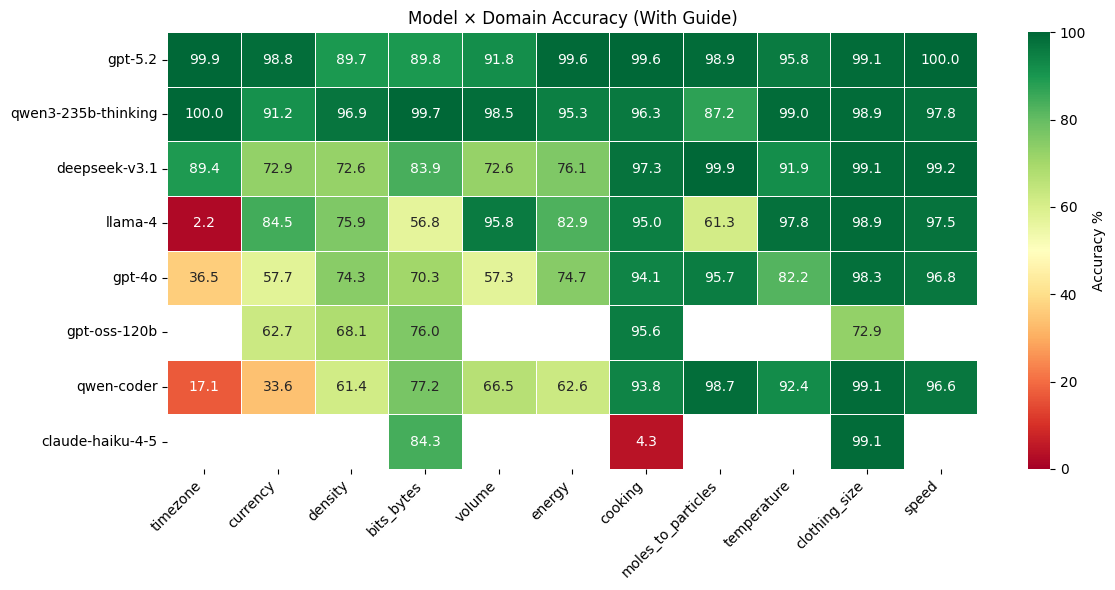

In [34]:
# make a regular (with guide) heatmap of accuracy by model, condition
heatmap_data_with_guide = (
    df_stats[df_stats['condition'] == 'in_domain_with_guide']
    .pivot(index='model', columns='domain', values='accuracy_%')
)
# sort rows (models) and columns (domains) by average accuracy descending
heatmap_data_with_guide = heatmap_data_with_guide.loc[
    heatmap_data_with_guide.mean(axis=1).sort_values(ascending=False).index,
    heatmap_data_with_guide.mean(axis=0).sort_values(ascending=True).index]

plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_data_with_guide,
    annot=True, fmt='.1f',       # show numbers in cells
    cmap='RdYlGn',      
    vmin=0, vmax=100,
    linewidths=0.5,
    cbar_kws={'label': 'Accuracy %'},
)
plt.title('Model × Domain Accuracy (With Guide)')
plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

relative difficulty of each domain

Text(0.5, 0, 'Accuracy (%)')

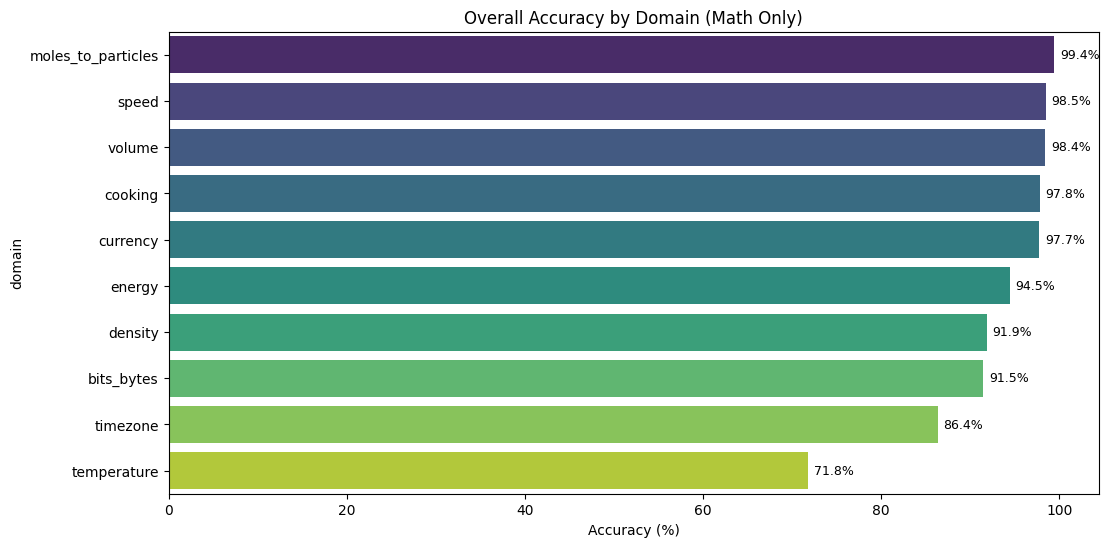

In [35]:
# get domain difficulty (overall) for math only
domain_avg = df_stats[df_stats['condition'] == 'math_only'].groupby('domain').agg({'accuracy_%': 'mean'}).sort_values('accuracy_%', ascending=False)
domain_avg
# plot domain difficulty
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='accuracy_%', y='domain', data=domain_avg, palette='viridis')
plt.title('Overall Accuracy by Domain (Math Only)')

# add accuracy labels on side of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=9, padding=4)

plt.xlabel('Accuracy (%)')

Text(0.5, 0, 'Accuracy (%)')

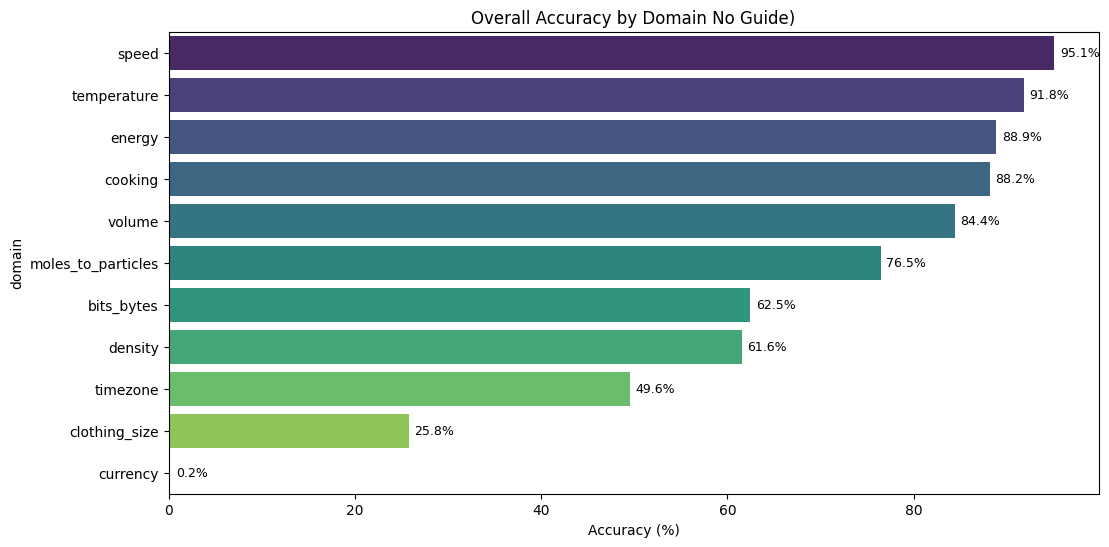

In [36]:
# no guide
# get domain difficulty (overall) for math only
domain_avg_no_guide = df_stats[df_stats['condition'] == 'in_domain_no_guide'].groupby('domain').agg({'accuracy_%': 'mean'}).sort_values('accuracy_%', ascending=False)
domain_avg_no_guide 
# plot domain difficulty
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='accuracy_%', y='domain', data=domain_avg_no_guide, palette='viridis')
plt.title('Overall Accuracy by Domain No Guide)')

# add accuracy labels on side of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=9, padding=4)

plt.xlabel('Accuracy (%)')

Text(0.5, 0, 'Accuracy (%)')

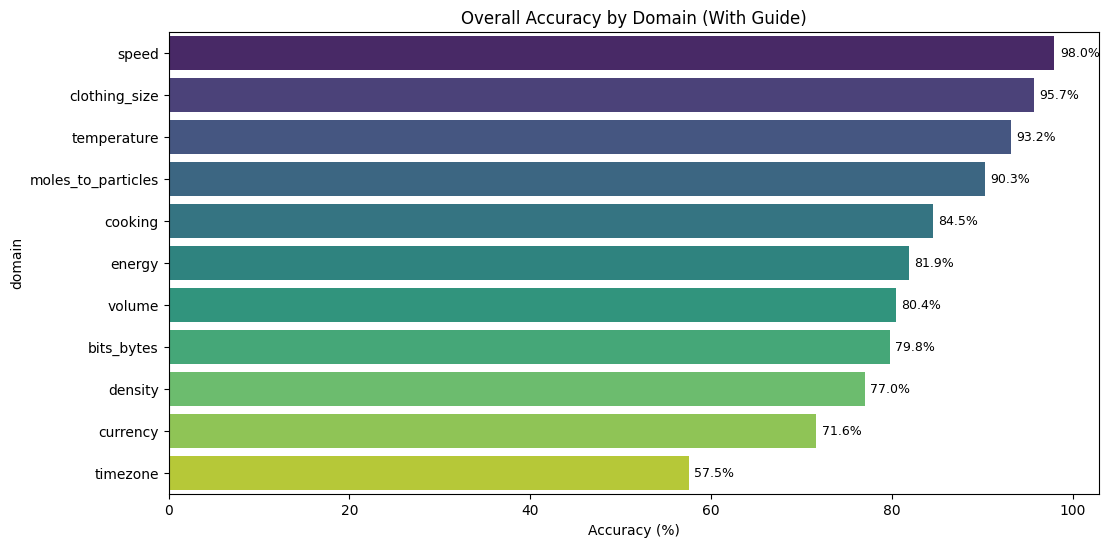

In [37]:
# get domain difficulty (overall) for math only
domain_avg_with_guide = df_stats[df_stats['condition'] == 'in_domain_with_guide'].groupby('domain').agg({'accuracy_%': 'mean'}).sort_values('accuracy_%', ascending=False)
domain_avg_with_guide
# plot domain difficulty
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='accuracy_%', y='domain', data=domain_avg_with_guide, palette='viridis')
plt.title('Overall Accuracy by Domain (With Guide)')

# add accuracy labels on side of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=9, padding=4)

plt.xlabel('Accuracy (%)')

In [44]:
df_freq_acc = df_all.groupby(['frequency'])['is_correct'].agg(['mean', 'count']).rename(columns={'mean': 'accuracy', 'count': 'n'}).reset_index()

In [45]:
df_freq_acc['accuracy_%'] = df_freq_acc['accuracy'].mul(100)

In [46]:
df_freq_acc['domain_difficulty'] = df_freq_acc['accuracy_%'].apply(lambda x: 'easy' if x > 50 else 'hard')
df_freq_acc.sample(20)

,frequency,accuracy,n,accuracy_%,domain_difficulty
27,71.0,0.806385,13062,80.638493,easy
39,133.0,0.755474,13062,75.547389,easy
49,405.0,0.782269,13062,78.226918,easy
118,1384788.0,0.656250,128,65.625000,easy
213,123335391.0,0.792937,14498,79.293696,easy
210,89560510.0,0.800688,14530,80.068823,easy
64,1243.0,0.754938,13062,75.493799,easy
207,65310257.0,0.818302,14370,81.830202,easy
0,1.0,0.665186,222876,66.518602,easy
154,7238850.0,0.778706,14370,77.870564,easy


In [47]:
df_freq_acc_with_models = df_all.groupby(['frequency', 'model', 'is_reasoning'])['is_correct'].agg(['mean', 'count']).rename(columns={'mean': 'accuracy', 'count': 'n'}).reset_index()

In [48]:
df_freq_acc_with_models['accuracy_%'] = df_freq_acc_with_models['accuracy'].mul(100)
df_freq_acc_with_models.sample(20)

,frequency,model,is_reasoning,accuracy,n,accuracy_%
924,2500553.0,claude-haiku-4-5,False,0.073529,204,7.352941
1601,858798582.0,llama-4,False,0.743860,2280,74.385965
337,656.0,qwen3-235b-thinking,True,0.973110,1971,97.311010
590,256800.0,gpt-4o,False,0.758333,2280,75.833333
1088,7902842.0,gpt-oss-120b,False,0.701087,1104,70.108696
1181,11222257.0,deepseek-v3.1,True,0.829528,1971,82.952816
580,238151.0,claude-haiku-4-5,False,0.500000,4,50.000000
1102,8851466.0,gpt-4o,False,0.778509,2280,77.850877
410,1582.0,deepseek-v3.1,True,0.782344,1971,78.234399
394,1337.0,gpt-5.2,True,0.903070,2280,90.307018


In [49]:
df_freq_acc_with_models['domain_difficulty'] = df_freq_acc_with_models['accuracy_%'].apply(lambda x: 'easy' if x > 50 else 'hard')
df_freq_acc_with_models.sample(20)

,frequency,model,is_reasoning,accuracy,n,accuracy_%,domain_difficulty
926,2500553.0,gpt-4o,False,0.753509,2280,75.350877,easy
1217,13695120.0,llama-4,False,0.808772,2280,80.877193,easy
1434,42381496.0,qwen-coder,False,0.689035,2280,68.903509,easy
1554,159553226.0,qwen-coder,False,0.727826,2300,72.782609,easy
511,36334.0,qwen3-235b-thinking,True,0.743278,1971,74.327752,easy
1528,123283982.0,gpt-oss-120b,False,0.693950,1124,69.395018,easy
1567,298385028.0,gpt-5.2,True,0.896673,2284,89.667250,easy
226,127.0,gpt-5.2,True,0.879825,2280,87.982456,easy
1236,14556990.0,claude-haiku-4-5,False,0.058824,204,5.882353,hard
827,1718423.0,qwen3-235b-thinking,True,0.869102,1971,86.910198,easy


skipping frequency in the pile for now because statistical markers weren't compelling

/tmp/ipykernel_1291258/3988960897.py:17: UserWarning: The palette list has more values (10) than needed (8), which may not be intended.
  ax = sns.barplot(data=df_dist_stats, x='has_distractor', y='accuracy_%', hue='model',


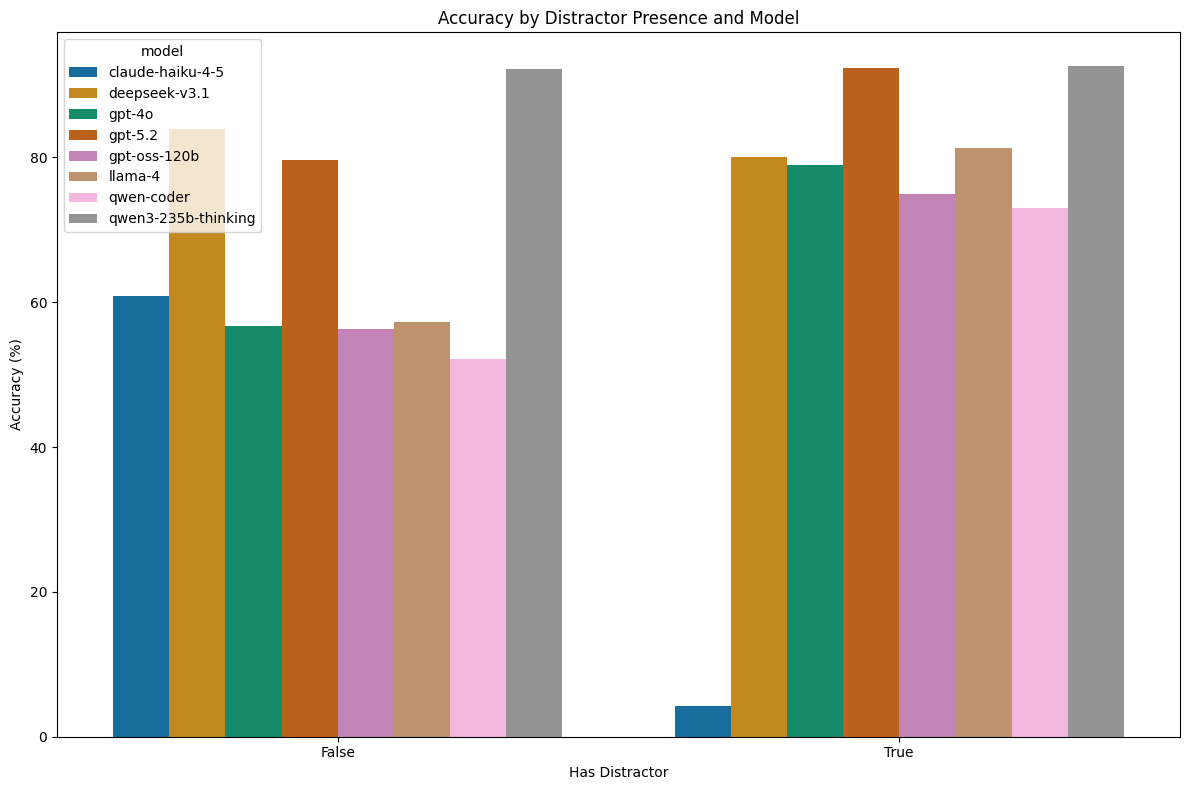

In [50]:
# plot accuracy by distractor or no distractor, by model
# Create a has_distractor flag on the raw data
df_all['has_distractor'] = df_all['distractor'].notna() & (df_all['distractor'] != 'null')

# Build stats grouped by has_distractor and model
df_dist_stats = (
    df_all
    .groupby(['model', 'has_distractor'])['is_correct']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'accuracy'})
    .reset_index()
)
df_dist_stats['accuracy_%'] = df_dist_stats['accuracy'].mul(100)

# Plot
plt.figure(figsize=(12, 8))
ax = sns.barplot(data=df_dist_stats, x='has_distractor', y='accuracy_%', hue='model',
            errorbar=('ci', 95), n_boot=10000, seed=42, palette=sns.color_palette('colorblind'),errwidth=2.5, capsize=0.15,)
plt.title('Accuracy by Distractor Presence and Model')
plt.xlabel('Has Distractor')
plt.ylabel('Accuracy (%)')
plt.tight_layout()
plt.show()

# add accuracy labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', fontsize=7, padding=8)

In [ ]:
# investigating timezone
df_timezone = df_all[(df_all['domain']=='timezone') & (df_all['condition']=='in_domain_no_guide')].copy()

# also keep aggregated stats for reference
df_timezone_stats = df_timezone.groupby(['frequency_level', 'condition', 'model']).agg({'is_correct': 'mean'}).reset_index()
df_timezone_stats['accuracy_%'] = df_timezone_stats['is_correct'].mul(100)


In [52]:
df_timezone.head()

,domain,distractor,prompt,number,answer,difficulty,raw_response,model_answer,loss,reasoning_tokens,...,frequency,frequency_level,is_reasoning,display_name,is_correct,num_decimals,num_input_decimals,raw_response_length,is_correct_pct,has_distractor
1750710,timezone,NaN,"Convert 1:00 AM in Los Angeles time to New York time. Assume you are thinking about standard time, not daylight savings. Provide the time in the same format (e.g., 1AM, 3:49PM).",1:00 AM,4:00 AM,Easy,<answer>4AM</answer>,4AM,0.0,0.0,...,1.0,rare,True,DeepSeek-V3.1 ★,True,0,0,20,100.0,False
1750711,timezone,NaN,"Convert 2:00 AM in Los Angeles time to New York time. Assume you are thinking about standard time, not daylight savings. Provide the time in the same format (e.g., 1AM, 3:49PM).",2:00 AM,5:00 AM,Easy,<answer>5:00AM</answer>,5:00AM,0.0,0.0,...,1.0,rare,True,DeepSeek-V3.1 ★,True,0,0,23,100.0,False
1750712,timezone,NaN,"Convert 3:00 AM in Los Angeles time to New York time. Assume you are thinking about standard time, not daylight savings. Provide the time in the same format (e.g., 1AM, 3:49PM).",3:00 AM,6:00 AM,Easy,<answer>6:00AM</answer>,6:00AM,0.0,0.0,...,1.0,rare,True,DeepSeek-V3.1 ★,True,0,0,23,100.0,False
1750713,timezone,NaN,"Convert 4:00 AM in Los Angeles time to New York time. Assume you are thinking about standard time, not daylight savings. Provide the time in the same format (e.g., 1AM, 3:49PM).",4:00 AM,7:00 AM,Easy,<answer>7:00AM</answer>,7:00AM,0.0,0.0,...,1.0,rare,True,DeepSeek-V3.1 ★,True,0,0,23,100.0,False
1750714,timezone,NaN,"Convert 5:00 AM in Los Angeles time to New York time. Assume you are thinking about standard time, not daylight savings. Provide the time in the same format (e.g., 1AM, 3:49PM).",5:00 AM,8:00 AM,Easy,<answer>8:00AM</answer>,8:00AM,0.0,0.0,...,1.0,rare,True,DeepSeek-V3.1 ★,True,0,0,23,100.0,False


In [55]:
df_timezone_stats

,frequency_level,condition,model,is_correct,accuracy_%
0,rare,in_domain_no_guide,deepseek-v3.1,0.777963,77.796296
1,rare,in_domain_no_guide,gpt-4o,0.198426,19.842593
2,rare,in_domain_no_guide,gpt-5.2,0.856019,85.601852
3,rare,in_domain_no_guide,llama-4,0.022222,2.222222
4,rare,in_domain_no_guide,qwen-coder,0.263704,26.370370
5,rare,in_domain_no_guide,qwen3-235b-thinking,0.855278,85.527778
6,uncommon,in_domain_no_guide,deepseek-v3.1,NaN,NaN
7,uncommon,in_domain_no_guide,gpt-4o,NaN,NaN
8,uncommon,in_domain_no_guide,gpt-5.2,NaN,NaN
9,uncommon,in_domain_no_guide,llama-4,NaN,NaN


In [56]:
# reasoning token length

import re

def extract_reasoning_text(raw):
    """Extract reasoning trace from raw_response, checking multiple formats.
    
    Priority:
      1. [REASONING]...[/REASONING] — api.py wraps reasoning_content from the API
      2. <think>...</think>          — inline thinking tags (some Qwen responses)
      3. everything before the last <answer> tag — fallback for models like DeepSeek
         that dump chain-of-thought directly into the content with no wrapper
    """
    if pd.isna(raw):
        return ''
    raw = str(raw)
    # 1. [REASONING]...[/REASONING]
    m = re.search(r'\[REASONING\]\s*(.*?)\s*\[/REASONING\]', raw, re.DOTALL)
    if m:
        return m.group(1).strip()
    # 2. <think>...</think>
    m = re.search(r'<think>(.*?)</think>', raw, re.DOTALL)
    if m:
        return m.group(1).strip()
    # 3. fallback: everything before the last <answer> tag is reasoning
    ans_matches = list(re.finditer(r'<answer>', raw, re.IGNORECASE))
    if ans_matches:
        reasoning_part = raw[:ans_matches[-1].start()].strip()
        # only count it if there's substantial text (>50 chars) to avoid
        # false positives from short preambles like "The answer is"
        if len(reasoning_part) > 50:
            return reasoning_part
    return ''

# only apply to reasoning models
df_reason = df_all[df_all['model'].isin(REASONING_MODELS)].copy()

# extract reasoning text and approximate token count (~0.75 words per token)
df_reason['reasoning_text'] = df_reason['raw_response'].apply(extract_reasoning_text)
df_reason['reasoning_word_count'] = df_reason['reasoning_text'].str.split().str.len().fillna(0).astype(int)
df_reason['reasoning_tokens_approx'] = (df_reason['reasoning_word_count'] / 0.75).round(0).astype(int)

# use API-provided reasoning_tokens where available, otherwise use approximation
df_reason['reasoning_tokens_final'] = df_reason['reasoning_tokens'].fillna(df_reason['reasoning_tokens_approx'])
# if API value is 0 but we have text, prefer approximation
mask_zero_api = (df_reason['reasoning_tokens_final'] == 0) & (df_reason['reasoning_tokens_approx'] > 0)
df_reason.loc[mask_zero_api, 'reasoning_tokens_final'] = df_reason.loc[mask_zero_api, 'reasoning_tokens_approx']

# filter to rows that actually have reasoning
df_reasoning = df_reason[df_reason['reasoning_tokens_final'] > 0].copy()

print(f"{len(df_reasoning):,} rows with reasoning traces (out of {len(df_reason):,} reasoning-model rows)")
print(f"Models: {df_reasoning['model'].unique().tolist()}")
print(f"\nSource breakdown:")
has_api = df_reasoning['reasoning_tokens'].notna() & (df_reasoning['reasoning_tokens'] > 0)
print(f"  API-provided reasoning_tokens: {has_api.sum():,}")
print(f"  Approximated from text:        {(~has_api).sum():,}")
print(f"\nSummary stats (reasoning_tokens_final):")
df_reasoning.groupby('model')['reasoning_tokens_final'].describe().round(0)

572,389 rows with reasoning traces (out of 1,343,706 reasoning-model rows)
Models: ['deepseek-v3.1', 'gpt-5.2', 'qwen3-235b-thinking']

Source breakdown:
  API-provided reasoning_tokens: 156,083
  Approximated from text:        416,306

Summary stats (reasoning_tokens_final):


,count,mean,std,min,25%,50%,75%,max
model,,,,,,,,
deepseek-v3.1,14102.0,260.0,679.0,1.0,48.0,77.0,128.0,9667.0
gpt-5.2,156083.0,382.0,447.0,2.0,90.0,216.0,507.0,16000.0
qwen3-235b-thinking,402204.0,1702.0,1580.0,47.0,492.0,1124.0,2436.0,14768.0


In [57]:
# reasoning by domain
df_reasoning.groupby(['domain', 'model'])['reasoning_tokens_final'].describe().round(0)
# reasoning by domain & condition
df_reasoning.groupby(['domain', 'condition', 'model'])['reasoning_tokens_final'].describe().round(0)


count    mean     std  \
domain     condition            model                                          
bits_bytes in_domain_no_guide   qwen3-235b-thinking   1200.0  1005.0  1212.0   
           in_domain_with_guide deepseek-v3.1            1.0    41.0     NaN   
                                qwen3-235b-thinking   1200.0  1400.0  1046.0   
           math_only            deepseek-v3.1            2.0    52.0    30.0   
                                qwen3-235b-thinking   1200.0   613.0   549.0   
...                                                      ...     ...     ...   
volume     in_domain_no_guide   qwen3-235b-thinking  37200.0  1616.0  1744.0   
           in_domain_with_guide deepseek-v3.1          666.0  2394.0  1159.0   
                                qwen3-235b-thinking  37197.0  2017.0  1606.0   
           math_only            deepseek-v3.1           22.0    57.0    97.0   
                                qwen3-235b-thinking   1200.0  1020.0   966.0   

                                                       min     25%     50%  \
domain     condition            model                                        
bits_bytes in_domain_no_guide   qwen3-235b-thinking  139.0   280.0   500.0   
           in_domain_with_guide deepseek-v3.1         41.0    41.0    41.0   
                                qwen3-235b-thinking  145.0   581.0  1150.0   
           math_only            deepseek-v3.1         31.0    42.0    52.0   
                                qwen3-235b-thinking  100.0   256.0   415.0   
...                                                    ...     ...     ...   
volume     in_domain_no_guide   qwen3-235b-thinking  103.0   439.0   756.0   
           in_domain_with_guide deepseek-v3.1         29.0  1640.0  2246.0   
                                qwen3-235b-thinking   92.0   805.0  1509.0   
           math_only            deepseek-v3.1          8.0    12.0    14.0   
                                qwen3-235b-thinking  104.0   341.0   594.0   

                                                        75%      max  
domain     condition            model                                 
bits_bytes in_domain_no_guide   qwen3-235b-thinking  1140.0   7375.0  
           in_domain_with_guide deepseek-v3.1          41.0     41.0  
                                qwen3-235b-thinking  1861.0   6348.0  
           math_only            deepseek-v3.1          62.0     73.0  
                                qwen3-235b-thinking   769.0   4020.0  
...                                                     ...      ...  
volume     in_domain_no_guide   qwen3-235b-thinking  2199.0  12316.0  
           in_domain_with_guide deepseek-v3.1        2968.0   7917.0  
                                qwen3-235b-thinking  2891.0   9264.0  
           math_only            deepseek-v3.1          79.0    461.0  
                                qwen3-235b-thinking  1411.0   5625.0  

[64 rows x 8 columns]

In [ ]:
df_reasoning_ng = df_reasoning[df_reasoning['condition'] == 'in_domain_no_guide'].copy()

In [ ]:
df_reasoning_ng['model'].unique()

array(['deepseek-v3.1', 'gpt-5.2', 'qwen3-235b-thinking'], dtype=object)

In [65]:
df_stats['model'].unique()

array(['claude-haiku-4-5', 'deepseek-v3.1', 'gpt-4o', 'gpt-5.2',
       'gpt-oss-120b', 'llama-4', 'qwen-coder', 'qwen3-235b-thinking'],
      dtype=object)

Models with no reasoning token data (will plot at 1 token): ['deepseek-v3.1', 'gpt-5.2']
33 points (model × condition × domain, reasoning models only)


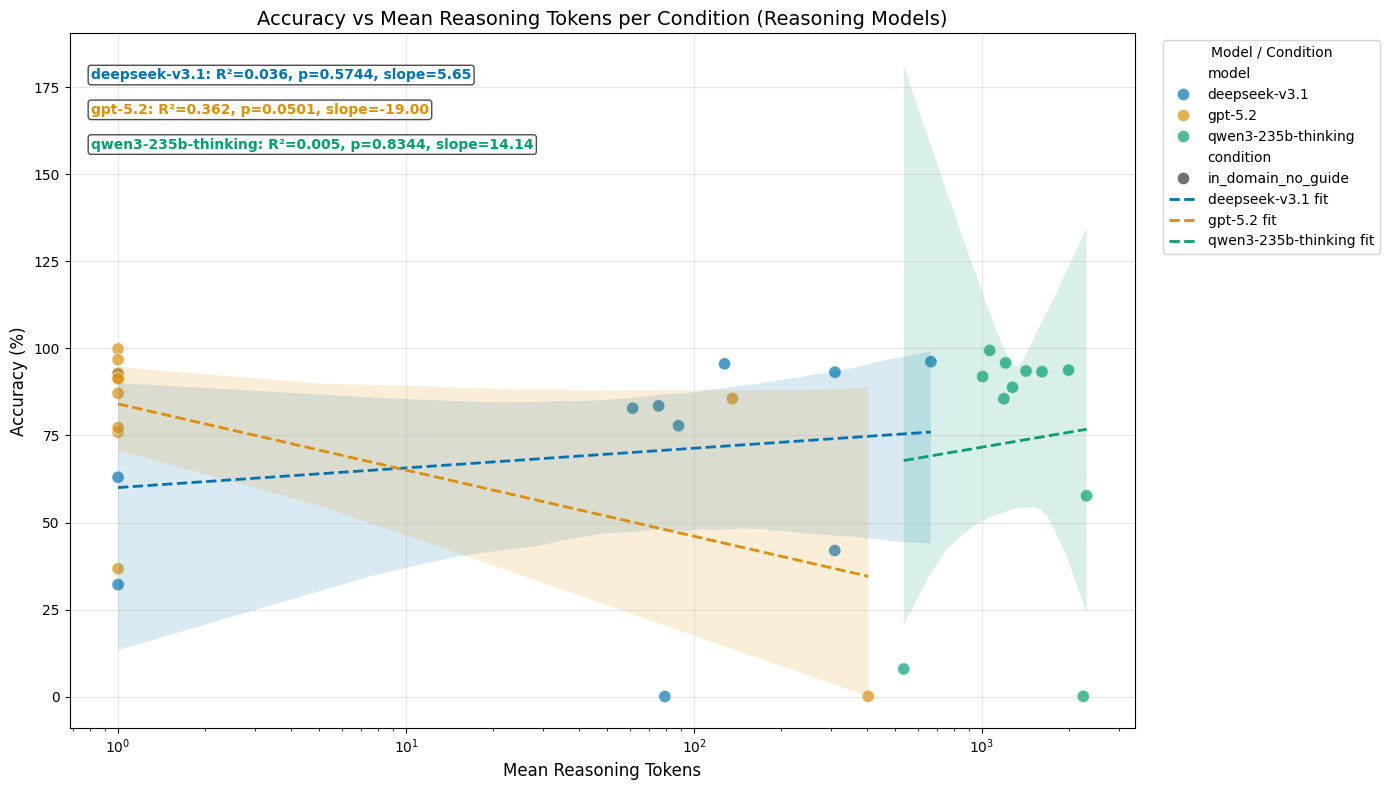

,model,slope,intercept,R²,p_value,std_err,n
1,gpt-5.2,-18.998,84.06,0.3622,5.01e-02,8.4029,11
0,deepseek-v3.1,5.648,60.04,0.0364,5.74e-01,9.6925,11
2,qwen3-235b-thinking,14.144,29.21,0.0051,8.34e-01,65.7093,11


In [66]:
# ── scatter: mean reasoning tokens (x) vs accuracy (y) per model × domain ──
# each dot = one model+condition+domain combo (reasoning models only)

# aggregate mean reasoning tokens at the same level as df_stats_ci
reasoning_agg = (
    df_reasoning_ng
    .groupby(['model', 'condition', 'domain'])['reasoning_tokens_final']
    .mean()
    .reset_index()
    .rename(columns={'reasoning_tokens_final': 'mean_reasoning_tokens'})
)

# start from stats for in_domain_no_guide so all reasoning models appear (even without token data)
stats_ng = df_stats[
    (df_stats['model'].isin(REASONING_MODELS)) & (df_stats['condition'] == 'in_domain_no_guide')
]
scatter_df = stats_ng.merge(
    reasoning_agg, on=['model', 'condition', 'domain'], how='left'
)
# show models missing from reasoning_agg (e.g. gpt-5.2 if API didn't return reasoning_tokens)
missing = scatter_df['mean_reasoning_tokens'].isna()
if missing.any():
    models_missing = scatter_df.loc[missing, 'model'].unique().tolist()
    print(f"Models with no reasoning token data (will plot at 1 token): {models_missing}")
scatter_df['mean_reasoning_tokens'] = scatter_df['mean_reasoning_tokens'].fillna(1.0)  # 1 so visible on log scale
print(f"{len(scatter_df)} points (model × condition × domain, reasoning models only)")

fig, ax = plt.subplots(figsize=(14, 8))
palette = sns.color_palette('colorblind', n_colors=scatter_df['model'].nunique())
model_colors = dict(zip(scatter_df['model'].unique(), palette))

sns.scatterplot(
    data=scatter_df, x='mean_reasoning_tokens', y='accuracy_%',
    hue='model', style='condition', s=80, alpha=0.7,
    palette=model_colors, ax=ax,
)

from scipy import stats

# per-model regression lines + stats
reasoning_reg_results = []
for model, color in model_colors.items():
    model_data = scatter_df[scatter_df['model'] == model].copy()
    model_data = model_data[model_data['mean_reasoning_tokens'] > 0]
    if len(model_data) > 2 and model_data['mean_reasoning_tokens'].nunique() > 1:
        model_data['log_tokens'] = np.log10(model_data['mean_reasoning_tokens'])
        sns.regplot(data=model_data, x='mean_reasoning_tokens', y='accuracy_%',
                    scatter=False, logx=True, ax=ax,
                    line_kws={'color': color, 'lw': 2, 'ls': '--'},
                    label=f'{model} fit')
        slope, intercept, r_value, p_value, std_err = stats.linregress(
            model_data['log_tokens'], model_data['accuracy_%']
        )
        reasoning_reg_results.append({
            'model': model, 'slope': slope, 'intercept': intercept,
            'R²': r_value ** 2, 'p_value': p_value, 'std_err': std_err, 'n': len(model_data)
        })

# annotate plot with stats
y_pos = 0.95
for res in reasoning_reg_results:
    color = model_colors[res['model']]
    p_str = f"{res['p_value']:.2e}" if res['p_value'] < 0.001 else f"{res['p_value']:.4f}"
    ax.text(0.02, y_pos, f"{res['model']}: R²={res['R²']:.3f}, p={p_str}, slope={res['slope']:.2f}",
            transform=ax.transAxes, fontsize=10, verticalalignment='top', color=color,
            fontweight='bold', bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))
    y_pos -= 0.05

ax.set_xlabel('Mean Reasoning Tokens', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Accuracy vs Mean Reasoning Tokens per Condition (Reasoning Models)', fontsize=14)
ax.legend(title='Model / Condition', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_xscale('log')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# summary table
df_reasoning_reg = pd.DataFrame(reasoning_reg_results).sort_values('p_value')
df_reasoning_reg.style.format({
    'slope': '{:.3f}', 'intercept': '{:.2f}', 'R²': '{:.4f}',
    'p_value': '{:.2e}', 'std_err': '{:.4f}', 'n': '{:d}'
}).background_gradient(subset=['R²'], cmap='Greens').background_gradient(subset=['p_value'], cmap='Reds_r')